In [5]:
!pip install -q tensorflow-datasets


TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/tf_flowers/incomplete.ALIHIC_3.0.1/tf_flowers-train.tfrecord-[0-9][0-9][0-…

Dataset tf_flowers downloaded and prepared to /root/tensorflow_datasets/tf_flowers/3.0.1. Subsequent calls will reuse this data.
Number of Classes: 5
Class Names: ['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']

Training CNN...
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 22s 145ms/step - accuracy: 0.4125 - loss: 1.4017 - val_accuracy: 0.5327 - val_loss: 1.1122
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - accuracy: 0.5783 - loss: 1.0263 - val_accuracy: 0.5736 - val_loss: 1.0273
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - accuracy: 0.6669 - loss: 0.8700 - val_accuracy: 0.6621 - val_loss: 0.8526
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - accuracy: 0.7425 - loss: 0.6809 - val_accuracy: 0.6689 - val_loss: 0.8787
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - accuracy: 0.8161 - loss: 0.5049 - val_accuracy: 0.6676 - val_loss: 0.9616

Training MobileNetV2...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 51s 350ms/step - accu

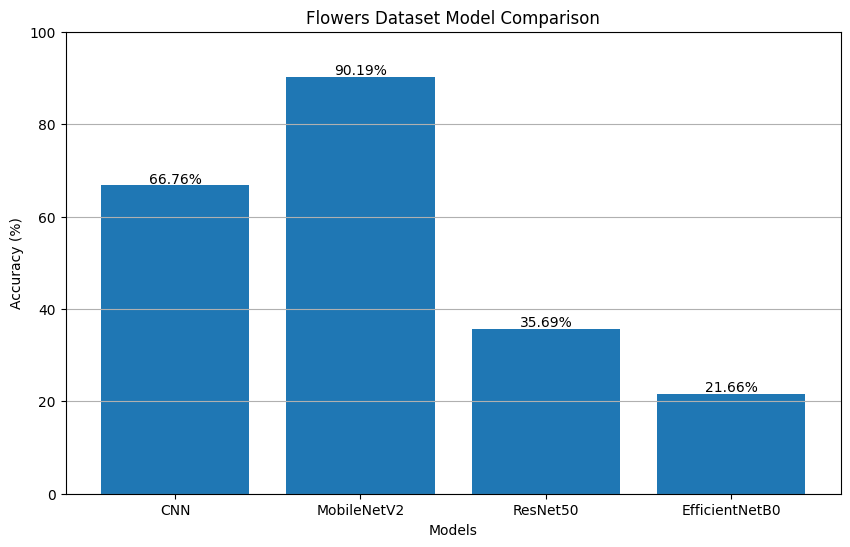


Best Model: MobileNetV2
Best Accuracy: 90.19 %


In [6]:

import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.applications import (
    MobileNetV2,
    ResNet50,
    EfficientNetB0
)
import gc

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

# =====================================================
# LOAD FLOWERS DATASET
# =====================================================

(train_ds_raw, test_ds_raw), ds_info = tfds.load(
    "tf_flowers",
    split=["train[:80%]", "train[80%:]"],
    as_supervised=True,
    with_info=True
)

NUM_CLASSES = ds_info.features["label"].num_classes

print("Number of Classes:", NUM_CLASSES)
print("Class Names:", ds_info.features["label"].names)

# =====================================================
# DATA PREPROCESSING
# =====================================================

IMG_SIZE = 224
BATCH_SIZE = 32

def preprocess(image, label):

    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))

    image = tf.cast(image, tf.float32) / 255.0

    return image, label

train_ds = (
    train_ds_raw
    .shuffle(1000)
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    test_ds_raw
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

results = {}

# =====================================================
# CUSTOM CNN
# =====================================================

print("\nTraining CNN...")

cnn = models.Sequential([

    layers.Input(shape=(224,224,3)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(NUM_CLASSES, activation='softmax')
])

cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn.fit(
    train_ds,
    epochs=5,
    validation_data=test_ds,
    verbose=1
)

loss, acc = cnn.evaluate(test_ds, verbose=0)

results["CNN"] = acc * 100

tf.keras.backend.clear_session()
gc.collect()

# =====================================================
# TRANSFER LEARNING FUNCTION
# =====================================================

def train_pretrained(base_model_fn, model_name):

    print(f"\nTraining {model_name}...")

    base_model = base_model_fn(
        weights="imagenet",
        include_top=False,
        input_shape=(224,224,3)
    )

    base_model.trainable = False

    model = models.Sequential([

        base_model,

        layers.GlobalAveragePooling2D(),

        layers.Dense(128, activation='relu'),

        layers.Dropout(0.3),

        layers.Dense(NUM_CLASSES, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    model.fit(
        train_ds,
        epochs=3,
        validation_data=test_ds,
        verbose=1
    )

    loss, acc = model.evaluate(
        test_ds,
        verbose=0
    )

    results[model_name] = acc * 100

    tf.keras.backend.clear_session()
    gc.collect()

# =====================================================
# TRAIN MODELS
# =====================================================

train_pretrained(
    MobileNetV2,
    "MobileNetV2"
)

train_pretrained(
    ResNet50,
    "ResNet50"
)

train_pretrained(
    EfficientNetB0,
    "EfficientNetB0"
)

# =====================================================
# RESULTS
# =====================================================

print("\n============================")
print("MODEL ACCURACY COMPARISON")
print("============================")

for model, accuracy in sorted(
        results.items(),
        key=lambda x: x[1],
        reverse=True):

    print(
        f"{model:15s} : {accuracy:.2f}%"
    )

# =====================================================
# BAR GRAPH
# =====================================================

model_names = list(results.keys())

accuracies = list(results.values())

plt.figure(figsize=(10,6))

bars = plt.bar(
    model_names,
    accuracies
)

plt.title(
    "Flowers Dataset Model Comparison"
)

plt.xlabel("Models")

plt.ylabel("Accuracy (%)")

for bar in bars:

    y = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        y + 0.5,
        f"{y:.2f}%",
        ha='center'
    )

plt.ylim(0,100)

plt.grid(axis='y')

plt.show()

# =====================================================
# BEST MODEL
# =====================================================

best_model = max(
    results,
    key=results.get
)

print("\nBest Model:", best_model)

print(
    "Best Accuracy:",
    round(results[best_model],2),
    "%"
)